# 1. Import Data and Dependencies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')               

In [2]:
etfs = pd.read_excel("dataset/ETFs.xlsx")
managed_funds = pd.read_excel("dataset/Managed Funds.xlsx")

print("ETFs Data Shape:", etfs.shape)
display(etfs.head())

print("Managed Funds Data Shape:", managed_funds.shape)
display(managed_funds.head())

ETFs Data Shape: (26890, 8)


,securityname,etf_issuer,fund_type,transaction_type,year_month,inflow,outflow,netflow
0,Beta Active Hybrids - BetaShares Active Aus Hy...,Betashares,Domestic Fixed Interest,Purchase,2022-01,1.121830e+07,0.00,1.121830e+07
1,Gblx Metals - Global X Physical Palladium A,Global X,Domestic Equity,Purchase,2022-01,7.802400e+02,0.00,7.802400e+02
2,Hyperion Global - Hyperion Gbl Growth Companie...,Hyperion,International Equity,Purchase,2022-01,1.120199e+06,0.00,1.120199e+06
3,iPath Series B S&P 500 VIX Short-Term Futures ...,NaN,International Equity,Purchase,2022-01,1.986000e+03,0.00,1.986000e+03
4,Ishs Global 100 Etf - iShares Global 100 ETF,BlackRock (iShares),International Equity,Sale,2022-01,0.000000e+00,-1360615.21,-1.360615e+06


Managed Funds Data Shape: (155668, 8)


,securityname,product_provider,fund_type,transaction_type,year_month,inflow,outflow,netflow
0,Investors Mutual Ltd - Investors Mutual Future...,Investors Mutual Ltd,Domestic Equity,Sale,2022-01,0.00,-477591.063167,-477591.063167
1,DNR Capital Pty Ltd - DNR Capital Australian E...,DNR Capital,Domestic Equity,Purchase,2022-01,244758.43,0.000000,244758.430000
2,MLC Investment Trust - MLC Real Return Asserti...,MLC,Blended,Sale,2022-01,0.00,-998327.860000,-998327.860000
3,Allan Gray Aust Pty Ltd - Allan Gray Australia...,Allan Gray Aust Pty Ltd,Domestic Equity,Purchase,2022-01,68044.07,0.000000,68044.070000
4,ClearView Life Nominees Pty Ltd - First Sentie...,First Sentier,International Equity,Purchase,2022-01,65793.97,0.000000,65793.970000


# 2. EDA

## 2.1 The Unique value of fund_type

In [3]:
etf_fund_types = sorted(etfs["fund_type"].dropna().unique())
managed_fund_types = sorted(managed_funds["fund_type"].dropna().unique())

print("Unique value of ETF fund_type:")
print(etf_fund_types)

print("Unique value of Managed Funds fund_type:")
print(managed_fund_types)

Unique value of ETF fund_type:
['Alternative', 'Blended', 'Domestic Cash', 'Domestic Equity', 'Domestic Fixed Interest', 'Domestic Property', 'International Cash', 'International Equity', 'International Fixed Interest', 'International Property']
Unique value of Managed Funds fund_type:
['Alternative', 'Blended', 'Domestic Cash', 'Domestic Equity', 'Domestic Fixed Interest', 'Domestic Property', 'International Cash', 'International Equity', 'International Fixed Interest', 'International Property', 'Other']


## 2.2 The Unique value of year_month

In [4]:
etfs_year_month_unique = (
    pd.to_datetime(etfs["year_month"], errors="coerce")
    .dropna()
    .drop_duplicates()
    .sort_values()
    .dt.strftime("%Y-%m")
)

managed_year_month_unique = (
    pd.to_datetime(managed_funds["year_month"], errors="coerce")
    .dropna()
    .drop_duplicates()
    .sort_values()
    .dt.strftime("%Y-%m")
)

print("The unique value of year_month for ETFs:")
print(etfs_year_month_unique.tolist())

print("The unique value of year_month for Managed Funds:")
print(managed_year_month_unique.tolist())

The unique value of year_month for ETFs:
['2022-01', '2022-02', '2022-03', '2022-04', '2022-05', '2022-06', '2022-07', '2022-08', '2022-09', '2022-10', '2022-11', '2022-12', '2023-01', '2023-02', '2023-03', '2023-04', '2023-05', '2023-06', '2023-07', '2023-08', '2023-09', '2023-10', '2023-11', '2023-12', '2024-01', '2024-02', '2024-03', '2024-04', '2024-05', '2024-06', '2024-07', '2024-08', '2024-09', '2024-10', '2024-11', '2024-12', '2025-01', '2025-02', '2025-03', '2025-04', '2025-05', '2025-06', '2025-07']
The unique value of year_month for Managed Funds:
['2022-01', '2022-02', '2022-03', '2022-04', '2022-05', '2022-06', '2022-07', '2022-08', '2022-09', '2022-10', '2022-11', '2022-12', '2023-01', '2023-02', '2023-03', '2023-04', '2023-05', '2023-06', '2023-07', '2023-08', '2023-09', '2023-10', '2023-11', '2023-12', '2024-01', '2024-02', '2024-03', '2024-04', '2024-05', '2024-06', '2024-07', '2024-08', '2024-09', '2024-10', '2024-11', '2024-12', '2025-01', '2025-02', '2025-03', '2025

<span style="color: green;">We can find that regardless of which table, the time range covered is from January 2022 to July 2025.</span>

## 2.3 Check the missing values

In [5]:
def check_missing(df, name):
    missing_count = df.isnull().sum()
    print("Number of missing values in each column:")
    print(missing_count)

check_missing(etfs, "ETFs")
check_missing(managed_funds, "Managed Funds")

Number of missing values in each column:
securityname          0
etf_issuer          612
fund_type             0
transaction_type      0
year_month            0
inflow                0
outflow               0
netflow               0
dtype: int64
Number of missing values in each column:
securityname        0
product_provider    0
fund_type           0
transaction_type    0
year_month          0
inflow              0
outflow             0
netflow             0
dtype: int64


<span style="color: green;">In both tables, due to the fact that there is only one variable with missing values, "etf_issuer", and this variable has little relevance to our analysis of this project, there will be no further handling of missing values in the future.</span>

## 2.4 View duplicate rows

In [6]:
def check_duplicates(df, name):    
    dup_count = df.duplicated().sum()
    print("The number of duplicate rows in", name, "is", dup_count)
    
print("Number of duplicate rows in ETFs:", check_duplicates(etfs, "ETFs"))
print("Number of duplicate rows in Managed Funds:", check_duplicates(managed_funds, "Managed Funds"))

The number of duplicate rows in ETFs is 0
Number of duplicate rows in ETFs: None
The number of duplicate rows in Managed Funds is 0
Number of duplicate rows in Managed Funds: None


## 2.5 Check how many funds are there

In [7]:
n_etfs = etfs["securityname"].nunique(dropna=True)
n_mf = managed_funds["securityname"].nunique(dropna=True)

print(f"The number of funds in the ETFs: {n_etfs}")
print(f"The number of funds in the Managed Funds: {n_mf}")

The number of funds in the ETFs: 782
The number of funds in the Managed Funds: 2999


## 2.6 Check how many funds are included in each fund_type?

In [8]:
def count_funds_by_type(df, name):
    df_clean = df.dropna(subset=["fund_type", "securityname"])
    grouped = df_clean.groupby("fund_type")
    fund_counts = grouped["securityname"].nunique()
    fund_counts = fund_counts.reset_index()
    fund_counts = fund_counts.rename(columns={"securityname": "fund_count"})
    fund_counts = fund_counts.sort_values(by="fund_count", ascending=False)
    print(name,": The number of funds in each fund_type")
    display(fund_counts)

    return fund_counts

etf_type_counts = count_funds_by_type(etfs, "ETFs")
mf_type_counts = count_funds_by_type(managed_funds, "Managed Funds")

ETFs : The number of funds in each fund_type


,fund_type,fund_count
7,International Equity,532
3,Domestic Equity,167
4,Domestic Fixed Interest,33
8,International Fixed Interest,19
1,Blended,8
0,Alternative,5
2,Domestic Cash,5
9,International Property,5
5,Domestic Property,4
6,International Cash,4


Managed Funds : The number of funds in each fund_type


,fund_type,fund_count
7,International Equity,729
1,Blended,695
3,Domestic Equity,596
4,Domestic Fixed Interest,266
10,Other,193
8,International Fixed Interest,141
5,Domestic Property,127
2,Domestic Cash,112
0,Alternative,77
9,International Property,62


<span style="color: green;">Due to the need to select one fund from each of the ETFs and Managed Funds tables and calculate its FTI to compare with funds of the same type, we should choose the fund category with as many funds as possible. If we operate in this way, our comparison can be presented more clearly.</span>

# 3. Data Preprocessing

## 3.1 Determine the type of fund

<span style="color: green;">According to 2.5, I found that whether in ETFs or Managed Funds, the International Equity contains the largest number of funds. Therefore, I have decided to select the fund to be analyzed in the International Equity fund type. The funds of other fund types are useless and can be dropped from our data table.</span>

In [9]:
selected_fund_type = "International Equity"

etfs_filtered = (
    etfs[etfs["fund_type"] == selected_fund_type]
    .copy()
    .reset_index(drop=True)
)

managed_funds_filtered = (
    managed_funds[managed_funds["fund_type"] == selected_fund_type]
    .copy()
    .reset_index(drop=True)
)

display(etfs_filtered.head())
display(managed_funds_filtered.head())

,securityname,etf_issuer,fund_type,transaction_type,year_month,inflow,outflow,netflow
0,Hyperion Global - Hyperion Gbl Growth Companie...,Hyperion,International Equity,Purchase,2022-01,1120198.65,0.00,1120198.65
1,iPath Series B S&P 500 VIX Short-Term Futures ...,NaN,International Equity,Purchase,2022-01,1986.00,0.00,1986.00
2,Ishs Global 100 Etf - iShares Global 100 ETF,BlackRock (iShares),International Equity,Sale,2022-01,0.00,-1360615.21,-1360615.21
3,GblX LNAS - Global X Ultra Long Nasdaq 100 Hed...,Global X,International Equity,Purchase,2022-01,24364.76,0.00,24364.76
4,Ishs Glob Health Etf - iShares Global Healthca...,BlackRock (iShares),International Equity,Purchase,2022-01,1046527.77,0.00,1046527.77


,securityname,product_provider,fund_type,transaction_type,year_month,inflow,outflow,netflow
0,ClearView Life Nominees Pty Ltd - First Sentie...,First Sentier,International Equity,Purchase,2022-01,65793.97,0.000000,65793.970000
1,Perpetual Investment Management Ltd - Perpetua...,MFS Int'l Aust Pty Ltd,International Equity,Contribution,2022-01,529.80,0.000000,529.800000
2,Fisher Investments Australasia - Fisher Invest...,BlackRock,International Equity,Purchase,2022-01,175235.02,0.000000,175235.020000
3,ClearBridge Investments Limited - Clearbridge ...,ClearBridge,International Equity,Sale,2022-01,0.00,-235640.080064,-235640.080064
4,Advance Asset Management Ltd - Wellington Glob...,Advance Asset Management,International Equity,Purchase,2022-01,24813.01,0.000000,24813.010000


## 3.2 Select one fund with the most coverage months as the analysis object

In [10]:
def count_months_per_fund(df, name):
    df_clean = df.dropna(subset=["securityname", "year_month"]).copy()
    df_clean["year_month"] = pd.to_datetime(df_clean["year_month"], errors="coerce")
    df_clean = df_clean.dropna(subset=["year_month"])

    fund_month_counts = (
        df_clean.groupby("securityname")["year_month"]
        .nunique()
        .reset_index()
        .rename(columns={"year_month": "month_count"})
        .sort_values(by=["month_count", "securityname"], ascending=[False, True])
        .reset_index(drop=True)
    )

    print(name, ": Number of months covered by each fund")
    with pd.option_context("display.max_colwidth", None):
        display(fund_month_counts.head())

    return fund_month_counts


etf_month_counts = count_months_per_fund(etfs_filtered, "ETFs")
mf_month_counts = count_months_per_fund(managed_funds_filtered, "Managed Funds")

ETFs : Number of months covered by each fund


,securityname,month_count
0,ARK Innovation ETF - ARK Innovation ETF,43
1,Antpds Globl Shrs - Antipodes Global Shares (Quoted Managed Fund),43
2,BETA DIV ALL GRO ETF - BetaShares Diversified All Growth ETF,43
3,BETA ETHI DIV HG ETF - BetaShares Ethical Diversified High Growth ETF,43
4,BETA S&P500 YIELDMAX - BetaShares S&P 500 Yield Maximiser (Managed Fund),43


Managed Funds : Number of months covered by each fund


,securityname,month_count
0,AMP Capital Investors - AMP Capital Wholesale Global Equity - Value Fund,43
1,AMP Capital Investors - Specialist International (Hedged) Share Fund - Class A Units,43
2,AMP Capital Investors - Specialist International Share Fund - Class A Units,43
3,ATLAS Infrastructure (Australia) - Atlas Infrastructure Australian Feeder Fund - Hedged,43
4,ATLAS Infrastructure (Australia) - Atlas Infrastructure Australian Feeder Fund - Unhedged,43


1. In the ETFs table, we select <span style="color: yellow;">"BETA ETHI DIV HG ETF - BetaShares Ethical Diversified High Growth ETF"</span>;
2. In the Managed Funds table, we select <span style="color: yellow;">"ATLAS Infrastructure (Australia) - Atlas Infrastructure Australian Feeder Fund - Hedged"</span>.

## 3.3 Reorganize the table by aggregating the entire table based on "securityname" and "year_month"

In [11]:
def aggregate_fund_month_table(df, provider_col):
    df_clean = df.copy()
    df_clean["year_month"] = pd.to_datetime(df_clean["year_month"], errors="coerce")
    df_clean = df_clean.dropna(subset=["securityname", "year_month"])

    aggregated_df = (
        df_clean.groupby(["securityname", "year_month"], as_index=False)
        .agg(
            {
                provider_col: "first",
                "fund_type": "first",
                "inflow": "sum",
                "outflow": "sum",
                "netflow": "sum",
            }
        )
        .sort_values(["securityname", "year_month"])
        .reset_index(drop=True)
    )

    aggregated_df["year_month"] = aggregated_df["year_month"].dt.strftime("%Y-%m")
    return aggregated_df


etfs_aggregated = aggregate_fund_month_table(etfs_filtered, "etf_issuer")
managed_funds_aggregated = aggregate_fund_month_table(managed_funds_filtered, "product_provider")

print("ETFs table after aggregating by securityname + year_month:")
display(etfs_aggregated.head())

print("Managed Funds table after aggregating by securityname + year_month:")
display(managed_funds_aggregated.head())

ETFs table after aggregating by securityname + year_month:


,securityname,year_month,etf_issuer,fund_type,inflow,outflow,netflow
0,21Shares Bitcoin Suisse Index - 21Shares Bitco...,2022-01,None,International Equity,0.000000,-31.540000,-31.540000
1,ALPS Clean Energy ETF - ALPS Clean Energy ETF,2024-02,None,International Equity,0.000000,-7018.578504,-7018.578504
2,ARK 21Shares Bitcoin ETF Common Shares of Bene...,2024-02,Ark Invest,International Equity,2181.456600,0.000000,2181.456600
3,ARK 21Shares Bitcoin ETF Common Shares of Bene...,2024-04,Ark Invest,International Equity,668.789149,0.000000,668.789149
4,ARK 21Shares Bitcoin ETF Common Shares of Bene...,2024-09,Ark Invest,International Equity,698.506893,0.000000,698.506893


Managed Funds table after aggregating by securityname + year_month:


,securityname,year_month,product_provider,fund_type,inflow,outflow,netflow
0,AMP Capital Funds Management Ltd - AMP Interna...,2022-01,AMP,International Equity,20805.65,-30270.39,-9464.74
1,AMP Capital Funds Management Ltd - AMP Interna...,2022-02,AMP,International Equity,20578.69,-34809.12,-14230.43
2,AMP Capital Funds Management Ltd - AMP Interna...,2022-03,AMP,International Equity,30420.62,-36244.35,-5823.73
3,AMP Capital Funds Management Ltd - AMP Interna...,2022-04,AMP,International Equity,23463.25,-100278.54,-76815.29
4,AMP Capital Funds Management Ltd - AMP Interna...,2022-05,AMP,International Equity,31829.36,-63640.73,-31811.37


## 3.4 Fill in the missing months' netflow to 0

In [12]:
# Because the two datasets span from January 2022 to July 2025
# But not every fund covers all months, so it is necessary to fill in the missing months and fill in netflow as 0

def fill_missing_months_with_zero(df, provider_col):
    df_clean = df.copy()
    df_clean["year_month"] = pd.to_datetime(df_clean["year_month"], errors="coerce")
    df_clean = df_clean.dropna(subset=["securityname", "year_month"])

    all_months = pd.date_range(
        start=df_clean["year_month"].min(),
        end=df_clean["year_month"].max(),
        freq="MS"
    )

    fund_info = (
        df_clean.groupby("securityname", as_index=False)
        .agg(
            {
                provider_col: "first",
                "fund_type": "first",
            }
        )
    )

    full_grid = pd.MultiIndex.from_product(
        [fund_info["securityname"], all_months],
        names=["securityname", "year_month"]
    ).to_frame(index=False)

    completed_df = (
        full_grid
        .merge(fund_info, on="securityname", how="left")
        .merge(
            df_clean[["securityname", "year_month", "inflow", "outflow", "netflow"]],
            on=["securityname", "year_month"],
            how="left"
        )
        .sort_values(["securityname", "year_month"])
        .reset_index(drop=True)
    )

    completed_df["inflow"] = completed_df["inflow"].fillna(0)
    completed_df["outflow"] = completed_df["outflow"].fillna(0)
    completed_df["netflow"] = completed_df["netflow"].fillna(0)

    completed_df["year_month"] = completed_df["year_month"].dt.strftime("%Y-%m")
    return completed_df


etfs_completed = fill_missing_months_with_zero(etfs_aggregated, "etf_issuer")
managed_funds_completed = fill_missing_months_with_zero(managed_funds_aggregated, "product_provider")

print("ETFs table after filling missing months with 0:")
display(etfs_completed.head())

print("Managed Funds table after filling missing months with 0:")
display(managed_funds_completed.head())

ETFs table after filling missing months with 0:


,securityname,year_month,etf_issuer,fund_type,inflow,outflow,netflow
0,21Shares Bitcoin Suisse Index - 21Shares Bitco...,2022-01,None,International Equity,0.0,-31.54,-31.54
1,21Shares Bitcoin Suisse Index - 21Shares Bitco...,2022-02,None,International Equity,0.0,0.00,0.00
2,21Shares Bitcoin Suisse Index - 21Shares Bitco...,2022-03,None,International Equity,0.0,0.00,0.00
3,21Shares Bitcoin Suisse Index - 21Shares Bitco...,2022-04,None,International Equity,0.0,0.00,0.00
4,21Shares Bitcoin Suisse Index - 21Shares Bitco...,2022-05,None,International Equity,0.0,0.00,0.00


Managed Funds table after filling missing months with 0:


,securityname,year_month,product_provider,fund_type,inflow,outflow,netflow
0,AMP Capital Funds Management Ltd - AMP Interna...,2022-01,AMP,International Equity,20805.65,-30270.39,-9464.74
1,AMP Capital Funds Management Ltd - AMP Interna...,2022-02,AMP,International Equity,20578.69,-34809.12,-14230.43
2,AMP Capital Funds Management Ltd - AMP Interna...,2022-03,AMP,International Equity,30420.62,-36244.35,-5823.73
3,AMP Capital Funds Management Ltd - AMP Interna...,2022-04,AMP,International Equity,23463.25,-100278.54,-76815.29
4,AMP Capital Funds Management Ltd - AMP Interna...,2022-05,AMP,International Equity,31829.36,-63640.73,-31811.37


# 4. FTI

## 4.1 Only retain key columns

In [13]:
# Two tables only retain the columns of 'secutiryname', 'year_month', and 'netflow'
etfs_fti = etfs_completed[["securityname", "year_month", "netflow"]]
managed_funds_fti = managed_funds_completed[["securityname", "year_month", "netflow"]]

display(etfs_fti.head())
display(managed_funds_fti.head())

,securityname,year_month,netflow
0,21Shares Bitcoin Suisse Index - 21Shares Bitco...,2022-01,-31.54
1,21Shares Bitcoin Suisse Index - 21Shares Bitco...,2022-02,0.00
2,21Shares Bitcoin Suisse Index - 21Shares Bitco...,2022-03,0.00
3,21Shares Bitcoin Suisse Index - 21Shares Bitco...,2022-04,0.00
4,21Shares Bitcoin Suisse Index - 21Shares Bitco...,2022-05,0.00


,securityname,year_month,netflow
0,AMP Capital Funds Management Ltd - AMP Interna...,2022-01,-9464.74
1,AMP Capital Funds Management Ltd - AMP Interna...,2022-02,-14230.43
2,AMP Capital Funds Management Ltd - AMP Interna...,2022-03,-5823.73
3,AMP Capital Funds Management Ltd - AMP Interna...,2022-04,-76815.29
4,AMP Capital Funds Management Ltd - AMP Interna...,2022-05,-31811.37


## 4.2 Computing growth_rate

In [14]:
# Add four columns: growth_rate_1M, growth_rate_3M, growth_rate_6M, growth_rate_12M
# Calculation rules:
# 1M:  (Current month netflow - Last month netflow) / Last month netflow
# 3M:  (3-month average net flow − starting-month net flow) / starting-month net flow
# 6M:  (6-month average net flow − starting-month net flow) / starting-month net flow
# 12M: (12-month average net flow − starting-month net flow) / starting-month net flow
# If the denominator is missing or 0, the growth rate is missing

def add_growth_rate_columns(df):
    df = df.copy()
    df["year_month"] = pd.to_datetime(df["year_month"], errors="coerce")
    df = df.sort_values(["securityname", "year_month"]).reset_index(drop=True)

    grouped_netflow = df.groupby("securityname")["netflow"]

    last_1m = grouped_netflow.shift(1)
    growth_1m = (df["netflow"] - last_1m) / last_1m
    df["growth_rate_1M"] = growth_1m.mask(last_1m.isna() | (last_1m == 0))

    for window in [3, 6, 12]:
        rolling_mean = grouped_netflow.transform(
            lambda s: s.rolling(window=window, min_periods=window).mean()
        )
        window_start = grouped_netflow.shift(window - 1)

        growth = (rolling_mean - window_start) / window_start
        df[f"growth_rate_{window}M"] = growth.mask(window_start.isna() | (window_start == 0))

    df["year_month"] = df["year_month"].dt.strftime("%Y-%m")
    return df


etfs_growth = add_growth_rate_columns(etfs_fti)
managed_funds_growth = add_growth_rate_columns(managed_funds_fti)

print("ETFs table with updated growth rates:")
display(etfs_growth.head())

print("Managed Funds table with updated growth rates:")
display(managed_funds_growth.head())


ETFs table with updated growth rates:


,securityname,year_month,netflow,growth_rate_1M,growth_rate_3M,growth_rate_6M,growth_rate_12M
0,21Shares Bitcoin Suisse Index - 21Shares Bitco...,2022-01,-31.54,NaN,NaN,NaN,NaN
1,21Shares Bitcoin Suisse Index - 21Shares Bitco...,2022-02,0.00,-1.0,NaN,NaN,NaN
2,21Shares Bitcoin Suisse Index - 21Shares Bitco...,2022-03,0.00,NaN,-0.666667,NaN,NaN
3,21Shares Bitcoin Suisse Index - 21Shares Bitco...,2022-04,0.00,NaN,NaN,NaN,NaN
4,21Shares Bitcoin Suisse Index - 21Shares Bitco...,2022-05,0.00,NaN,NaN,NaN,NaN


Managed Funds table with updated growth rates:


,securityname,year_month,netflow,growth_rate_1M,growth_rate_3M,growth_rate_6M,growth_rate_12M
0,AMP Capital Funds Management Ltd - AMP Interna...,2022-01,-9464.74,NaN,NaN,NaN,NaN
1,AMP Capital Funds Management Ltd - AMP Interna...,2022-02,-14230.43,0.503520,NaN,NaN,NaN
2,AMP Capital Funds Management Ltd - AMP Interna...,2022-03,-5823.73,-0.590755,0.039609,NaN,NaN
3,AMP Capital Funds Management Ltd - AMP Interna...,2022-04,-76815.29,12.190050,1.269068,NaN,NaN
4,AMP Capital Funds Management Ltd - AMP Interna...,2022-05,-31811.37,-0.585872,5.550807,NaN,NaN


## 4.3 Calculate the monthly ranking for each fund based on netflow growth rate

In [15]:
# Add four columns: rank_1M, rank_3M, rank_6M, rank_12M
# Calculation rules:        
# rank_1M: Sort within each month based on growth_rate_1M, with higher growth rates ranked higher (rank=1)
# rank_3M: Sort within each month based on growth_rate_3M
# rank_6M: Sort within each month based on growth_rate_6M
# rank_12M: Sort within each month based on growth_rate_12M 
# If the growth rate is missing, the rank is also missing

def add_monthly_rank_columns(df):
    df = df.copy()

    rank_map = {
        "growth_rate_1M": "rank_1M",
        "growth_rate_3M": "rank_3M",
        "growth_rate_6M": "rank_6M",
        "growth_rate_12M": "rank_12M",
    }

    for growth_col, rank_col in rank_map.items():
        df[rank_col] = (
            df.groupby("year_month")[growth_col]
            .rank(method="min", ascending=False)
        )

    return df


etfs_ranked = add_monthly_rank_columns(etfs_growth)
managed_funds_ranked = add_monthly_rank_columns(managed_funds_growth)

print("ETFs table with monthly ranks:")
display(etfs_ranked.head())

print("Managed Funds table with monthly ranks:")
display(managed_funds_ranked.head())


ETFs table with monthly ranks:


,securityname,year_month,netflow,growth_rate_1M,growth_rate_3M,growth_rate_6M,growth_rate_12M,rank_1M,rank_3M,rank_6M,rank_12M
0,21Shares Bitcoin Suisse Index - 21Shares Bitco...,2022-01,-31.54,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,21Shares Bitcoin Suisse Index - 21Shares Bitco...,2022-02,0.00,-1.0,NaN,NaN,NaN,94.0,NaN,NaN,NaN
2,21Shares Bitcoin Suisse Index - 21Shares Bitco...,2022-03,0.00,NaN,-0.666667,NaN,NaN,NaN,98.0,NaN,NaN
3,21Shares Bitcoin Suisse Index - 21Shares Bitco...,2022-04,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,21Shares Bitcoin Suisse Index - 21Shares Bitco...,2022-05,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Managed Funds table with monthly ranks:


,securityname,year_month,netflow,growth_rate_1M,growth_rate_3M,growth_rate_6M,growth_rate_12M,rank_1M,rank_3M,rank_6M,rank_12M
0,AMP Capital Funds Management Ltd - AMP Interna...,2022-01,-9464.74,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AMP Capital Funds Management Ltd - AMP Interna...,2022-02,-14230.43,0.503520,NaN,NaN,NaN,132.0,NaN,NaN,NaN
2,AMP Capital Funds Management Ltd - AMP Interna...,2022-03,-5823.73,-0.590755,0.039609,NaN,NaN,244.0,205.0,NaN,NaN
3,AMP Capital Funds Management Ltd - AMP Interna...,2022-04,-76815.29,12.190050,1.269068,NaN,NaN,19.0,73.0,NaN,NaN
4,AMP Capital Funds Management Ltd - AMP Interna...,2022-05,-31811.37,-0.585872,5.550807,NaN,NaN,234.0,21.0,NaN,NaN


## 4.4 Ranking percentage

In [16]:
# Add four columns: rank_1M_percent, rank_3M_percent, rank_6M_percent, rank_12M_percent
# Calculation rules:
# (number of non-missing funds in the current month − rank) / (number of non-missing funds in the current month − 1)
# If the number of non-missing funds in the current month is less than or equal to 1, or if the rank is missing, then set the value to missing.

def add_rank_percent_columns(df):
    df = df.copy()

    rank_map = {
        "rank_1M": "rank_1M_percent",
        "rank_3M": "rank_3M_percent",
        "rank_6M": "rank_6M_percent",
        "rank_12M": "rank_12M_percent",
    }

    for rank_col, percent_col in rank_map.items():
        valid_count = df.groupby("year_month")[rank_col].transform("count")
        df[percent_col] = (valid_count - df[rank_col]) / (valid_count - 1)
        df.loc[(valid_count <= 1) | (df[rank_col].isna()), percent_col] = pd.NA

    return df


etfs_final = add_rank_percent_columns(etfs_ranked)
managed_funds_final = add_rank_percent_columns(managed_funds_ranked)

print("ETFs table with rank percentages:")
display(etfs_final.head())

print("Managed Funds table with rank percentages:")
display(managed_funds_final.head())


ETFs table with rank percentages:


,securityname,year_month,netflow,growth_rate_1M,growth_rate_3M,growth_rate_6M,growth_rate_12M,rank_1M,rank_3M,rank_6M,rank_12M,rank_1M_percent,rank_3M_percent,rank_6M_percent,rank_12M_percent
0,21Shares Bitcoin Suisse Index - 21Shares Bitco...,2022-01,-31.54,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,21Shares Bitcoin Suisse Index - 21Shares Bitco...,2022-02,0.00,-1.0,NaN,NaN,NaN,94.0,NaN,NaN,NaN,0.474576,NaN,NaN,NaN
2,21Shares Bitcoin Suisse Index - 21Shares Bitco...,2022-03,0.00,NaN,-0.666667,NaN,NaN,NaN,98.0,NaN,NaN,NaN,0.451977,NaN,NaN
3,21Shares Bitcoin Suisse Index - 21Shares Bitco...,2022-04,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,21Shares Bitcoin Suisse Index - 21Shares Bitco...,2022-05,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Managed Funds table with rank percentages:


,securityname,year_month,netflow,growth_rate_1M,growth_rate_3M,growth_rate_6M,growth_rate_12M,rank_1M,rank_3M,rank_6M,rank_12M,rank_1M_percent,rank_3M_percent,rank_6M_percent,rank_12M_percent
0,AMP Capital Funds Management Ltd - AMP Interna...,2022-01,-9464.74,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AMP Capital Funds Management Ltd - AMP Interna...,2022-02,-14230.43,0.503520,NaN,NaN,NaN,132.0,NaN,NaN,NaN,0.718280,NaN,NaN,NaN
2,AMP Capital Funds Management Ltd - AMP Interna...,2022-03,-5823.73,-0.590755,0.039609,NaN,NaN,244.0,205.0,NaN,NaN,0.482979,0.561290,NaN,NaN
3,AMP Capital Funds Management Ltd - AMP Interna...,2022-04,-76815.29,12.190050,1.269068,NaN,NaN,19.0,73.0,NaN,NaN,0.961864,0.846809,NaN,NaN
4,AMP Capital Funds Management Ltd - AMP Interna...,2022-05,-31811.37,-0.585872,5.550807,NaN,NaN,234.0,21.0,NaN,NaN,0.506356,0.957627,NaN,NaN


## 4.5 Final Indicator (FTI)

In [17]:
# Change column name:
# rank_1M_percent to FTI
# rank_3M_percent to FTI_3M
# rank_6M_percent to FTI_6M
# rank_12M_percent to FTI_12M

def rename_fti_columns(df):
    df = df.copy()
    df = df.rename(
        columns={
            "rank_1M_percent": "FTI",
            "rank_3M_percent": "FTI_3M",
            "rank_6M_percent": "FTI_6M",
            "rank_12M_percent": "FTI_12M",
        }
    )
    return df


etfs_fti = rename_fti_columns(etfs_final)
managed_funds_fti = rename_fti_columns(managed_funds_final)

print("ETFs table with final FTI indicators:")
display(etfs_fti.head())

print("Managed Funds table with final FTI indicators:")
display(managed_funds_fti.head())

ETFs table with final FTI indicators:


,securityname,year_month,netflow,growth_rate_1M,growth_rate_3M,growth_rate_6M,growth_rate_12M,rank_1M,rank_3M,rank_6M,rank_12M,FTI,FTI_3M,FTI_6M,FTI_12M
0,21Shares Bitcoin Suisse Index - 21Shares Bitco...,2022-01,-31.54,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,21Shares Bitcoin Suisse Index - 21Shares Bitco...,2022-02,0.00,-1.0,NaN,NaN,NaN,94.0,NaN,NaN,NaN,0.474576,NaN,NaN,NaN
2,21Shares Bitcoin Suisse Index - 21Shares Bitco...,2022-03,0.00,NaN,-0.666667,NaN,NaN,NaN,98.0,NaN,NaN,NaN,0.451977,NaN,NaN
3,21Shares Bitcoin Suisse Index - 21Shares Bitco...,2022-04,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,21Shares Bitcoin Suisse Index - 21Shares Bitco...,2022-05,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Managed Funds table with final FTI indicators:


,securityname,year_month,netflow,growth_rate_1M,growth_rate_3M,growth_rate_6M,growth_rate_12M,rank_1M,rank_3M,rank_6M,rank_12M,FTI,FTI_3M,FTI_6M,FTI_12M
0,AMP Capital Funds Management Ltd - AMP Interna...,2022-01,-9464.74,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AMP Capital Funds Management Ltd - AMP Interna...,2022-02,-14230.43,0.503520,NaN,NaN,NaN,132.0,NaN,NaN,NaN,0.718280,NaN,NaN,NaN
2,AMP Capital Funds Management Ltd - AMP Interna...,2022-03,-5823.73,-0.590755,0.039609,NaN,NaN,244.0,205.0,NaN,NaN,0.482979,0.561290,NaN,NaN
3,AMP Capital Funds Management Ltd - AMP Interna...,2022-04,-76815.29,12.190050,1.269068,NaN,NaN,19.0,73.0,NaN,NaN,0.961864,0.846809,NaN,NaN
4,AMP Capital Funds Management Ltd - AMP Interna...,2022-05,-31811.37,-0.585872,5.550807,NaN,NaN,234.0,21.0,NaN,NaN,0.506356,0.957627,NaN,NaN


In [18]:
# drop growth_rate_1M, growth_rate_3M, growth_rate_6M, growth_rate_12M
etfs_fti = etfs_fti.drop(columns=["growth_rate_1M", "growth_rate_3M", "growth_rate_6M", "growth_rate_12M"])
managed_funds_fti = managed_funds_fti.drop(columns=["growth_rate_1M", "growth_rate_3M", "growth_rate_6M", "growth_rate_12M"])

# drop rank_1M, rank_3M, rank_6M, rank_12M
etfs_fti = etfs_fti.drop(columns=["rank_1M", "rank_3M", "rank_6M", "rank_12M"])
managed_funds_fti = managed_funds_fti.drop(columns=["rank_1M", "rank_3M", "rank_6M", "rank_12M"])

display(etfs_fti.head())
display(managed_funds_fti.head())


,securityname,year_month,netflow,FTI,FTI_3M,FTI_6M,FTI_12M
0,21Shares Bitcoin Suisse Index - 21Shares Bitco...,2022-01,-31.54,NaN,NaN,NaN,NaN
1,21Shares Bitcoin Suisse Index - 21Shares Bitco...,2022-02,0.00,0.474576,NaN,NaN,NaN
2,21Shares Bitcoin Suisse Index - 21Shares Bitco...,2022-03,0.00,NaN,0.451977,NaN,NaN
3,21Shares Bitcoin Suisse Index - 21Shares Bitco...,2022-04,0.00,NaN,NaN,NaN,NaN
4,21Shares Bitcoin Suisse Index - 21Shares Bitco...,2022-05,0.00,NaN,NaN,NaN,NaN


,securityname,year_month,netflow,FTI,FTI_3M,FTI_6M,FTI_12M
0,AMP Capital Funds Management Ltd - AMP Interna...,2022-01,-9464.74,NaN,NaN,NaN,NaN
1,AMP Capital Funds Management Ltd - AMP Interna...,2022-02,-14230.43,0.718280,NaN,NaN,NaN
2,AMP Capital Funds Management Ltd - AMP Interna...,2022-03,-5823.73,0.482979,0.561290,NaN,NaN
3,AMP Capital Funds Management Ltd - AMP Interna...,2022-04,-76815.29,0.961864,0.846809,NaN,NaN
4,AMP Capital Funds Management Ltd - AMP Interna...,2022-05,-31811.37,0.506356,0.957627,NaN,NaN


## 4.6 FTI's de-seasonal variant

In [19]:
# 1. Due to the calculations in Sections 4.1–4.5, we filled the netflow values of months with missing data as 0. However, a large number of zero-filled missing values would affect the calculation of the “seasonal component,” causing it to become almost entirely zero. Therefore, we use the “aggregation table without zero imputation” for estimation, in order to avoid the issue where the seasonal component becomes nearly all zeros due to the extensive zero-filling performed in Section 3.4.
# 2. Seasonal component calculation method: For each fund_type and each calendar month (1–12), the median of the netflow values is used as the “seasonal component.”
# 3. Deseasonalized netflow = original netflow − the seasonal component of the corresponding month
# 4. Subsequently, the methods in Sections 4.2–4.5 are applied to calculate the deseasonalized FTI.

def add_seasonal_and_deseasonalized_flow(completed_df, aggregated_df):
    completed = completed_df[["securityname", "fund_type", "year_month", "netflow"]].copy()
    completed["year_month"] = pd.to_datetime(completed["year_month"], errors="coerce")
    completed = completed.sort_values(["securityname", "year_month"]).reset_index(drop=True)

    reference = aggregated_df[["securityname", "fund_type", "year_month", "netflow"]].copy()
    reference["year_month"] = pd.to_datetime(reference["year_month"], errors="coerce")
    reference = reference.dropna(subset=["year_month"]).copy()
    reference["calendar_month"] = reference["year_month"].dt.month

    seasonal_table = (
        reference.groupby(["fund_type", "calendar_month"], as_index=False)["netflow"]
        .median()
        .rename(columns={"netflow": "seasonal_component"})
    )

    completed["calendar_month"] = completed["year_month"].dt.month
    completed = completed.merge(
        seasonal_table,
        on=["fund_type", "calendar_month"],
        how="left"
    )

    completed["netflow_deseasonalized"] = (
        completed["netflow"] - completed["seasonal_component"]
    )

    completed["year_month"] = completed["year_month"].dt.strftime("%Y-%m")
    return completed


def build_deseasonalized_fti(ds_base_df):
    calc_df = ds_base_df[["securityname", "year_month", "netflow_deseasonalized"]].copy()
    calc_df = calc_df.rename(columns={"netflow_deseasonalized": "netflow"})

    calc_df = add_growth_rate_columns(calc_df)
    calc_df = add_monthly_rank_columns(calc_df)
    calc_df = add_rank_percent_columns(calc_df)
    calc_df = rename_fti_columns(calc_df)

    calc_df = calc_df.rename(
        columns={
            "netflow": "netflow_deseasonalized",
            "FTI": "FTI_DS",
            "FTI_3M": "FTI_DS_3M",
            "FTI_6M": "FTI_DS_6M",
            "FTI_12M": "FTI_DS_12M",
        }
    )

    calc_df = calc_df.drop(
        columns=[
            "growth_rate_1M", "growth_rate_3M", "growth_rate_6M", "growth_rate_12M",
            "rank_1M", "rank_3M", "rank_6M", "rank_12M",
        ]
    )

    result = ds_base_df.merge(
        calc_df[
            [
                "securityname", "year_month",
                "FTI_DS", "FTI_DS_3M", "FTI_DS_6M", "FTI_DS_12M"
            ]
        ],
        on=["securityname", "year_month"],
        how="left"
    )

    return result


In [20]:
etfs_ds_base = add_seasonal_and_deseasonalized_flow(
    etfs_completed,
    etfs_aggregated
)
etfs_fti_ds = build_deseasonalized_fti(etfs_ds_base)

managed_funds_ds_base = add_seasonal_and_deseasonalized_flow(
    managed_funds_completed,
    managed_funds_aggregated
)
managed_funds_fti_ds = build_deseasonalized_fti(managed_funds_ds_base)

print("ETFs table with de-seasonalised FTI:")
display(etfs_fti_ds.head())

print("Managed Funds table with de-seasonalised FTI:")
display(managed_funds_fti_ds.head())


ETFs table with de-seasonalised FTI:


,securityname,fund_type,year_month,netflow,calendar_month,seasonal_component,netflow_deseasonalized,FTI_DS,FTI_DS_3M,FTI_DS_6M,FTI_DS_12M
0,21Shares Bitcoin Suisse Index - 21Shares Bitco...,International Equity,2022-01,-31.54,1,24708.295000,-24739.835000,NaN,NaN,NaN,NaN
1,21Shares Bitcoin Suisse Index - 21Shares Bitco...,International Equity,2022-02,0.00,2,15826.050000,-15826.050000,0.254237,NaN,NaN,NaN
2,21Shares Bitcoin Suisse Index - 21Shares Bitco...,International Equity,2022-03,0.00,3,24297.320000,-24297.320000,0.903955,0.288136,NaN,NaN
3,21Shares Bitcoin Suisse Index - 21Shares Bitco...,International Equity,2022-04,0.00,4,5529.260000,-5529.260000,0.834275,0.807910,NaN,NaN
4,21Shares Bitcoin Suisse Index - 21Shares Bitco...,International Equity,2022-05,0.00,5,1286.640317,-1286.640317,0.806026,0.789077,NaN,NaN


Managed Funds table with de-seasonalised FTI:


,securityname,fund_type,year_month,netflow,calendar_month,seasonal_component,netflow_deseasonalized,FTI_DS,FTI_DS_3M,FTI_DS_6M,FTI_DS_12M
0,AMP Capital Funds Management Ltd - AMP Interna...,International Equity,2022-01,-9464.74,1,897.55001,-10362.29001,NaN,NaN,NaN,NaN
1,AMP Capital Funds Management Ltd - AMP Interna...,International Equity,2022-02,-14230.43,2,48.24000,-14278.67000,0.770289,NaN,NaN,NaN
2,AMP Capital Funds Management Ltd - AMP Interna...,International Equity,2022-03,-5823.73,3,4.18000,-5827.91000,0.652473,0.668501,NaN,NaN
3,AMP Capital Funds Management Ltd - AMP Interna...,International Equity,2022-04,-76815.29,4,228.41000,-77043.70000,0.642857,0.868132,NaN,NaN
4,AMP Capital Funds Management Ltd - AMP Interna...,International Equity,2022-05,-31811.37,5,-44.36000,-31767.01000,0.660714,0.648352,NaN,NaN


# 5. My FTI 🆚 FTI of Peer Average

## 5.1 ETFs

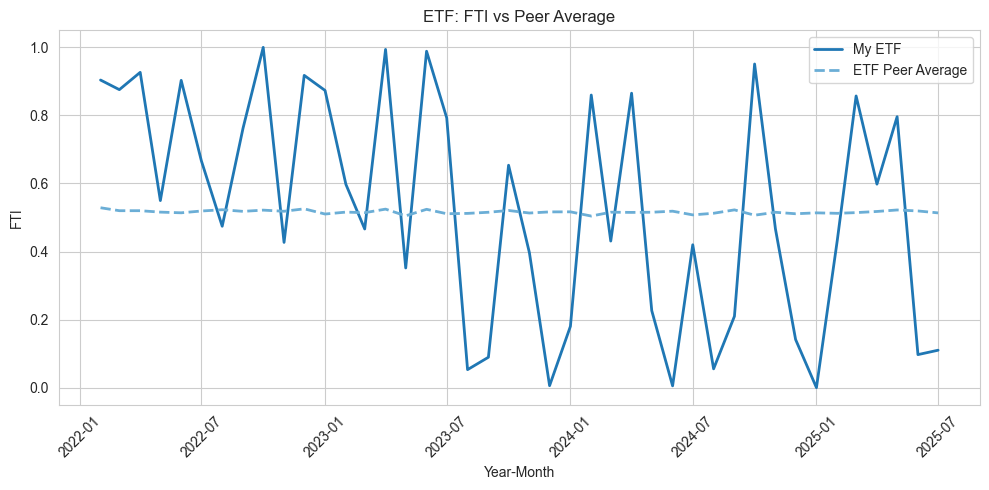

In [21]:
# ETF：FTI vs Peer Average

selected_etf_name = "BETA ETHI DIV HG ETF - BetaShares Ethical Diversified High Growth ETF"

etf_plot_df = etfs_fti.copy()
etf_plot_df["year_month"] = pd.to_datetime(etf_plot_df["year_month"], errors="coerce")

metrics = ["FTI", "FTI_3M", "FTI_6M", "FTI_12M"]

etf_avg = (
    etf_plot_df.groupby("year_month", as_index=False)[metrics]
    .mean()
    .rename(columns={col: f"{col}_avg" for col in metrics})
)

selected_etf = (
    etf_plot_df[etf_plot_df["securityname"] == selected_etf_name]
    .sort_values("year_month")
    .merge(etf_avg, on="year_month", how="left")
    .reset_index(drop=True)
)

sns.set_style("whitegrid")

metric = "FTI"
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    selected_etf["year_month"],
    selected_etf[metric],
    label="My ETF",
    linewidth=2,
    color="#1f77b4",
)
ax.plot(
    selected_etf["year_month"],
    selected_etf[f"{metric}_avg"],
    label="ETF Peer Average",
    linewidth=2,
    linestyle="--",
    color="#6baed6",
)
ax.set_title(f"ETF: {metric} vs Peer Average")
ax.set_xlabel("Year-Month")
ax.set_ylabel(metric)
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

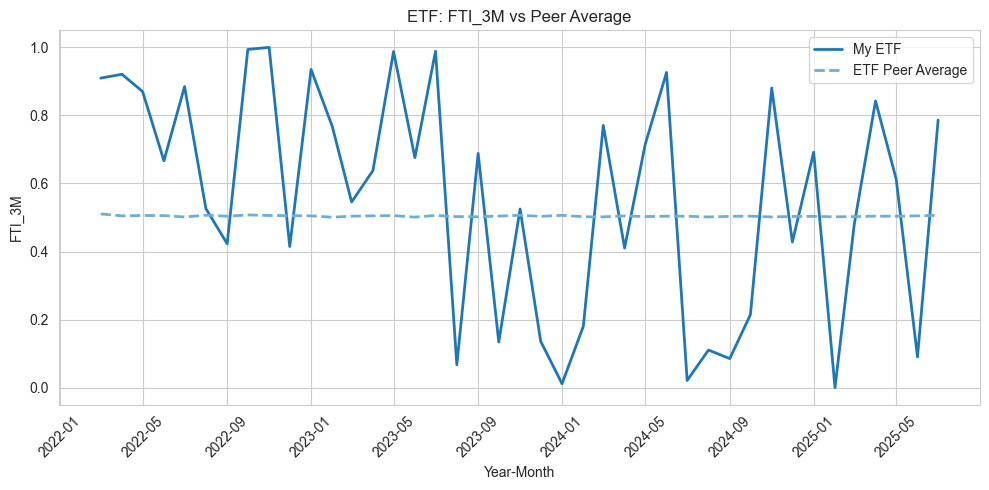

In [22]:
# ETF：FTI_3M vs Peer Average

metric = "FTI_3M"
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    selected_etf["year_month"],
    selected_etf[metric],
    label="My ETF",
    linewidth=2,
    color="#1f77b4",
)
ax.plot(
    selected_etf["year_month"],
    selected_etf[f"{metric}_avg"],
    label="ETF Peer Average",
    linewidth=2,
    linestyle="--",
    color="#6baed6",
)
ax.set_title(f"ETF: {metric} vs Peer Average")
ax.set_xlabel("Year-Month")
ax.set_ylabel(metric)
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

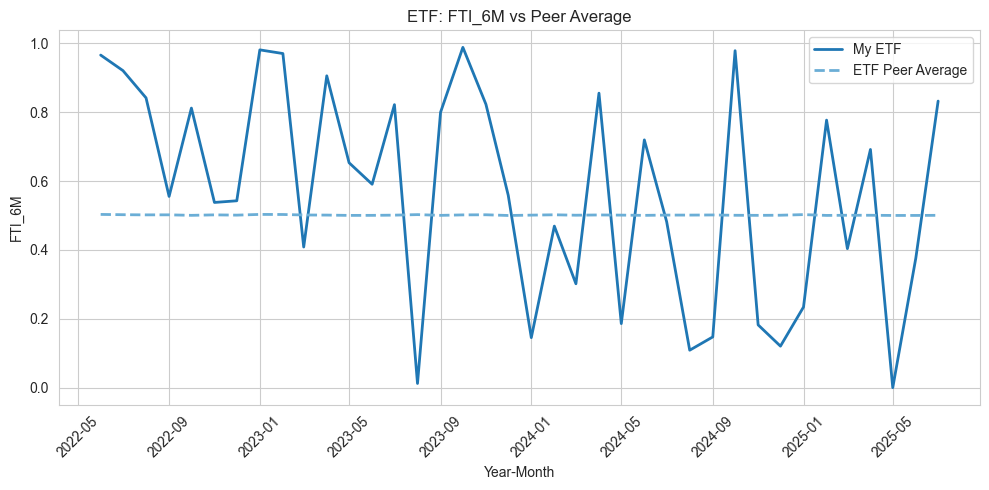

In [23]:
# ETF：FTI_6M vs Peer Average

metric = "FTI_6M"
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    selected_etf["year_month"],
    selected_etf[metric],
    label="My ETF",
    linewidth=2,
    color="#1f77b4",
)
ax.plot(
    selected_etf["year_month"],
    selected_etf[f"{metric}_avg"],
    label="ETF Peer Average",
    linewidth=2,
    linestyle="--",
    color="#6baed6",
)
ax.set_title(f"ETF: {metric} vs Peer Average")
ax.set_xlabel("Year-Month")
ax.set_ylabel(metric)
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

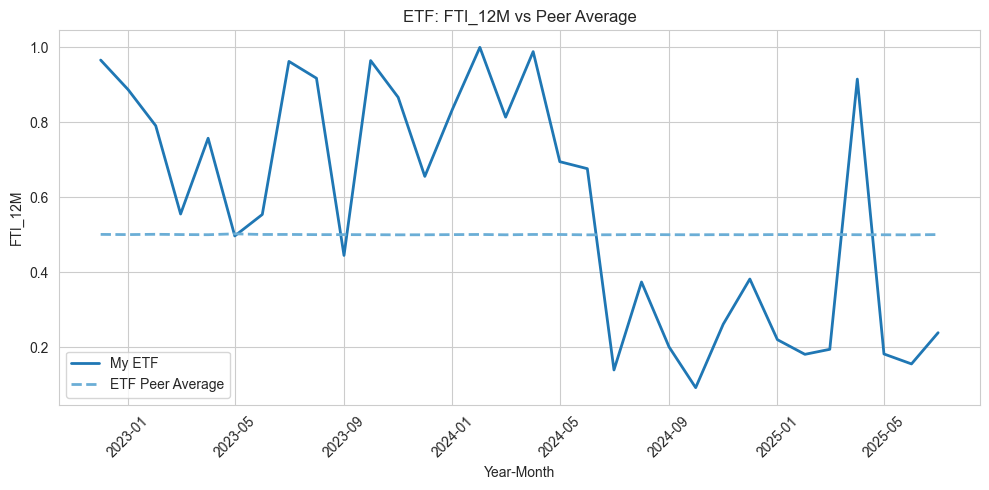

In [24]:
# ETF：FTI_12M vs Peer Average

metric = "FTI_12M"
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    selected_etf["year_month"],
    selected_etf[metric],
    label="My ETF",
    linewidth=2,
    color="#1f77b4",
)
ax.plot(
    selected_etf["year_month"],
    selected_etf[f"{metric}_avg"],
    label="ETF Peer Average",
    linewidth=2,
    linestyle="--",
    color="#6baed6",
)
ax.set_title(f"ETF: {metric} vs Peer Average")
ax.set_xlabel("Year-Month")
ax.set_ylabel(metric)
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

## 5.2 Managed fund

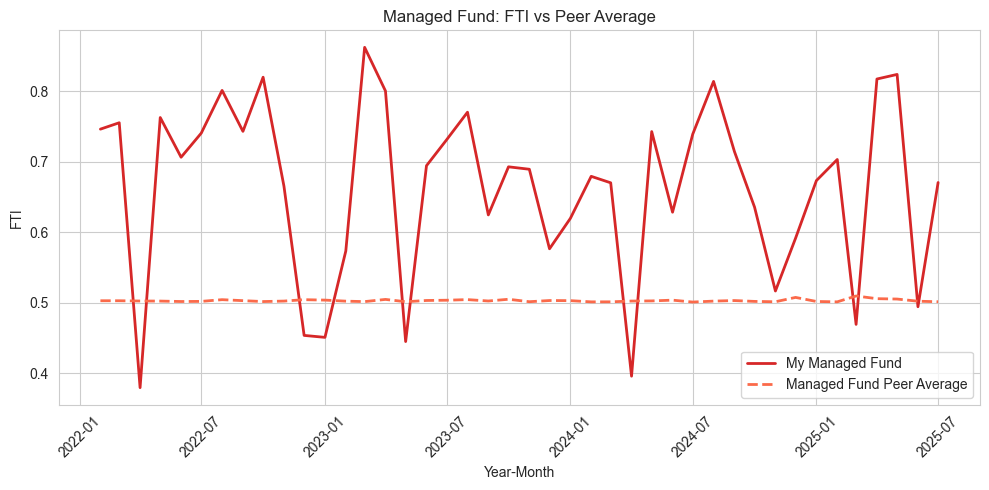

In [25]:
# Managed Fund：FTI vs Peer Average

selected_mf_name = "ATLAS Infrastructure (Australia) - Atlas Infrastructure Australian Feeder Fund - Hedged"

mf_plot_df = managed_funds_fti.copy()
mf_plot_df["year_month"] = pd.to_datetime(mf_plot_df["year_month"], errors="coerce")

metrics = ["FTI", "FTI_3M", "FTI_6M", "FTI_12M"]

mf_avg = (
    mf_plot_df.groupby("year_month", as_index=False)[metrics]
    .mean()
    .rename(columns={col: f"{col}_avg" for col in metrics})
)

selected_mf = (
    mf_plot_df[mf_plot_df["securityname"] == selected_mf_name]
    .sort_values("year_month")
    .merge(mf_avg, on="year_month", how="left")
    .reset_index(drop=True)
)

sns.set_style("whitegrid")

metric = "FTI"
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    selected_mf["year_month"],
    selected_mf[metric],
    label="My Managed Fund",
    linewidth=2,
    color="#d62728",
)
ax.plot(
    selected_mf["year_month"],
    selected_mf[f"{metric}_avg"],
    label="Managed Fund Peer Average",
    linewidth=2,
    linestyle="--",
    color="#fb6a4a",
)
ax.set_title(f"Managed Fund: {metric} vs Peer Average")
ax.set_xlabel("Year-Month")
ax.set_ylabel(metric)
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

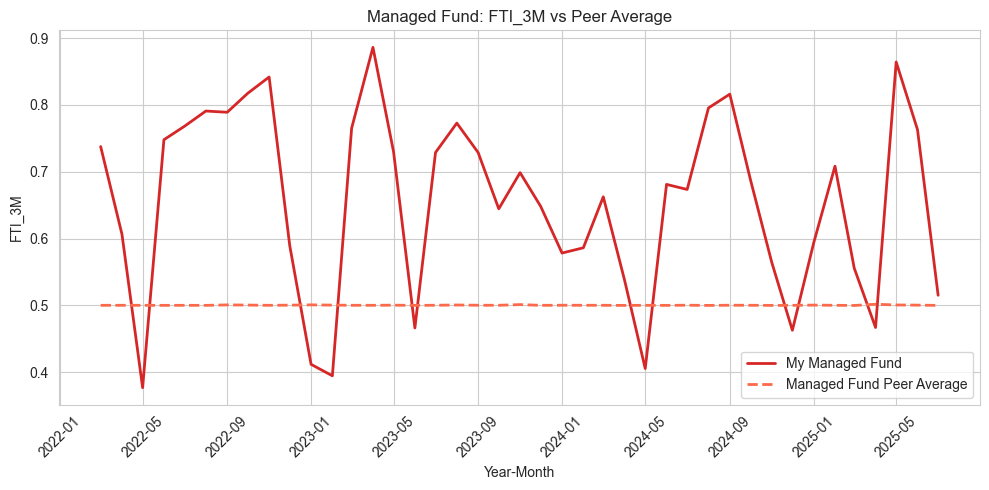

In [26]:
# Managed Fund：FTI_3M vs Peer Average

metric = "FTI_3M"
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    selected_mf["year_month"],
    selected_mf[metric],
    label="My Managed Fund",
    linewidth=2,
    color="#d62728",
)
ax.plot(
    selected_mf["year_month"],
    selected_mf[f"{metric}_avg"],
    label="Managed Fund Peer Average",
    linewidth=2,
    linestyle="--",
    color="#fb6a4a",
)
ax.set_title(f"Managed Fund: {metric} vs Peer Average")
ax.set_xlabel("Year-Month")
ax.set_ylabel(metric)
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

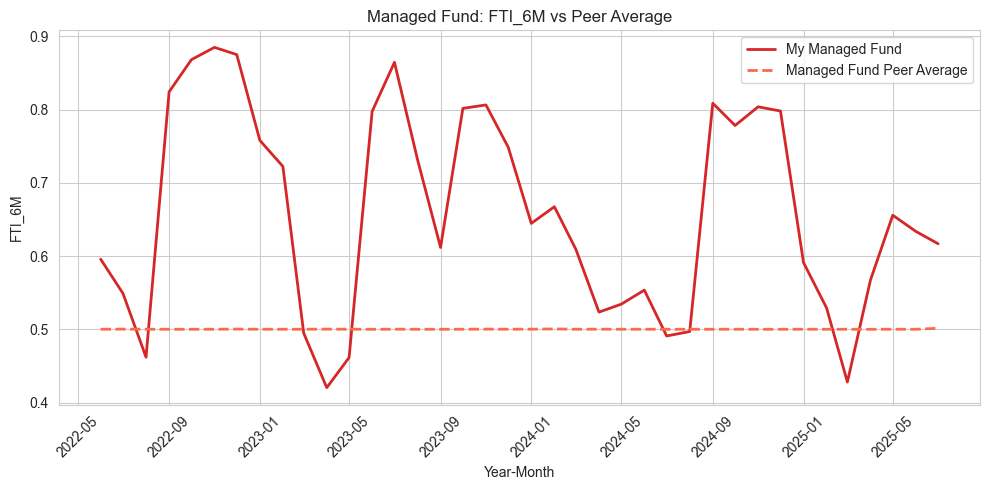

In [27]:
# Managed Fund：FTI_6M vs Peer Average

metric = "FTI_6M"
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    selected_mf["year_month"],
    selected_mf[metric],
    label="My Managed Fund",
    linewidth=2,
    color="#d62728",
)
ax.plot(
    selected_mf["year_month"],
    selected_mf[f"{metric}_avg"],
    label="Managed Fund Peer Average",
    linewidth=2,
    linestyle="--",
    color="#fb6a4a",
)
ax.set_title(f"Managed Fund: {metric} vs Peer Average")
ax.set_xlabel("Year-Month")
ax.set_ylabel(metric)
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

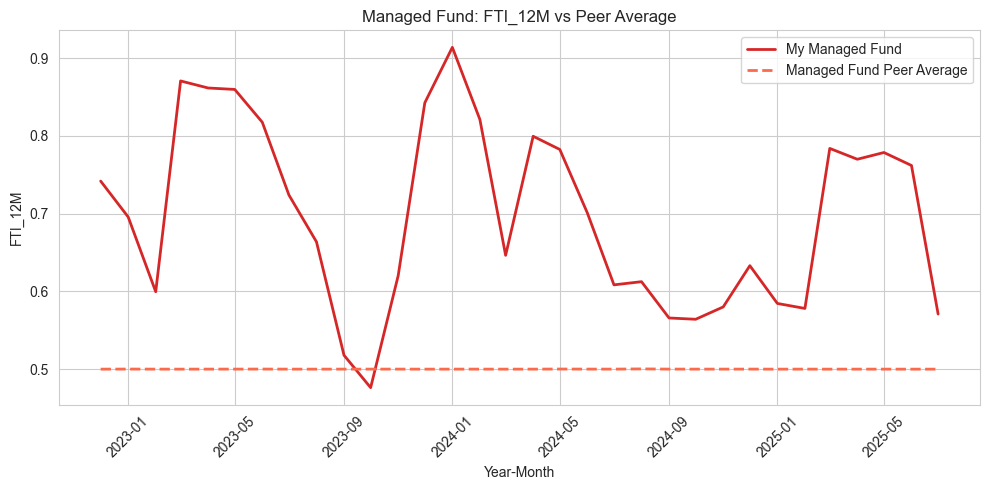

In [28]:
# Managed Fund：FTI_12M vs Peer Average

metric = "FTI_12M"
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    selected_mf["year_month"],
    selected_mf[metric],
    label="My Managed Fund",
    linewidth=2,
    color="#d62728",
)
ax.plot(
    selected_mf["year_month"],
    selected_mf[f"{metric}_avg"],
    label="Managed Fund Peer Average",
    linewidth=2,
    linestyle="--",
    color="#fb6a4a",
)
ax.set_title(f"Managed Fund: {metric} vs Peer Average")
ax.set_xlabel("Year-Month")
ax.set_ylabel(metric)
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

## 5.3 De-seasonalised variant

In [29]:
# 5.3.1 ETFs: De-seasonalised FTI vs Peer Average

selected_etf_name = "BETA ETHI DIV HG ETF - BetaShares Ethical Diversified High Growth ETF"

etf_ds_plot_df = etfs_fti_ds.copy()
etf_ds_plot_df["year_month"] = pd.to_datetime(etf_ds_plot_df["year_month"], errors="coerce")

ds_metrics = ["FTI_DS", "FTI_DS_3M", "FTI_DS_6M", "FTI_DS_12M"]

etf_ds_avg = (
    etf_ds_plot_df.groupby("year_month", as_index=False)[ds_metrics]
    .mean()
    .rename(columns={col: f"{col}_avg" for col in ds_metrics})
)

selected_etf_ds = (
    etf_ds_plot_df[etf_ds_plot_df["securityname"] == selected_etf_name]
    .sort_values("year_month")
    .merge(etf_ds_avg, on="year_month", how="left")
    .reset_index(drop=True)
)

sns.set_style("whitegrid")


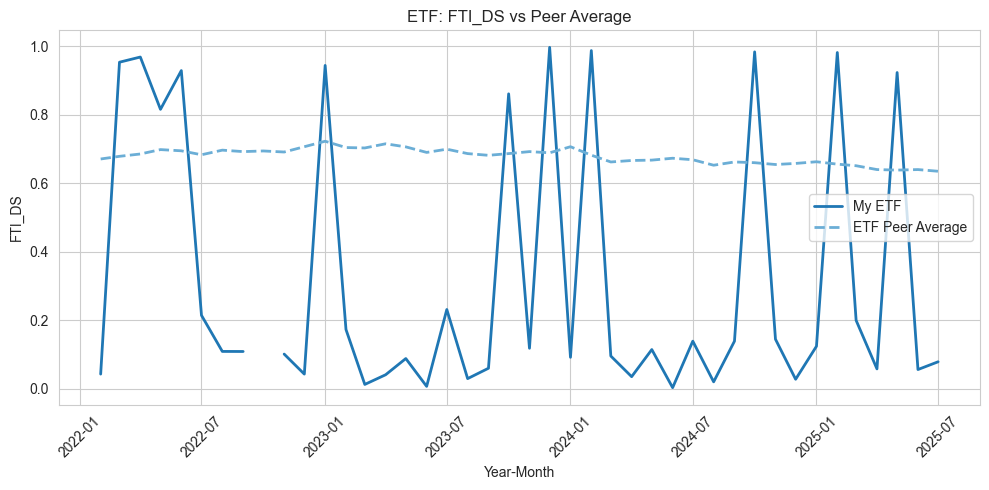

In [30]:
# ETF: FTI_DS vs Peer Average

metric = "FTI_DS"
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    selected_etf_ds["year_month"],
    selected_etf_ds[metric],
    label="My ETF",
    linewidth=2,
    color="#1f77b4",
)
ax.plot(
    selected_etf_ds["year_month"],
    selected_etf_ds[f"{metric}_avg"],
    label="ETF Peer Average",
    linewidth=2,
    linestyle="--",
    color="#6baed6",
)
ax.set_title(f"ETF: {metric} vs Peer Average")
ax.set_xlabel("Year-Month")
ax.set_ylabel(metric)
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.show()


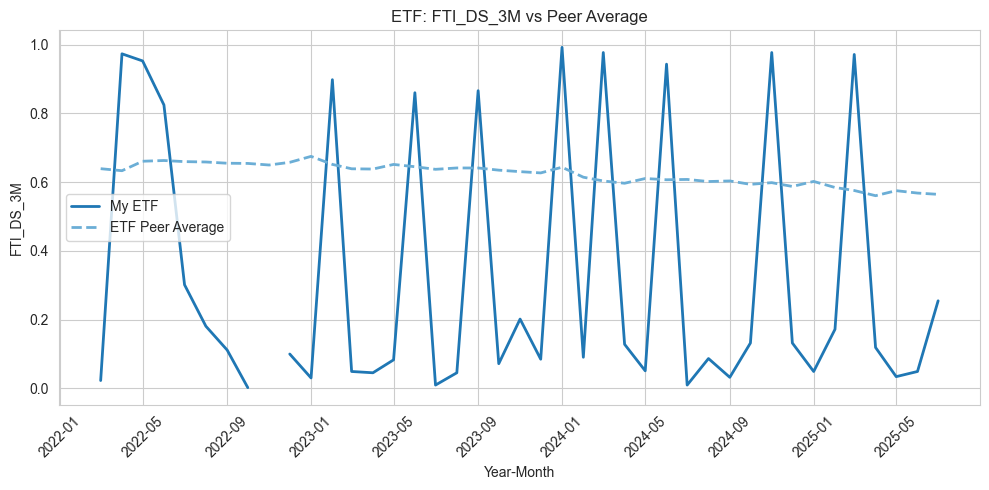

In [31]:
# ETF: FTI_DS_3M vs Peer Average

metric = "FTI_DS_3M"
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    selected_etf_ds["year_month"],
    selected_etf_ds[metric],
    label="My ETF",
    linewidth=2,
    color="#1f77b4",
)
ax.plot(
    selected_etf_ds["year_month"],
    selected_etf_ds[f"{metric}_avg"],
    label="ETF Peer Average",
    linewidth=2,
    linestyle="--",
    color="#6baed6",
)
ax.set_title(f"ETF: {metric} vs Peer Average")
ax.set_xlabel("Year-Month")
ax.set_ylabel(metric)
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.show()


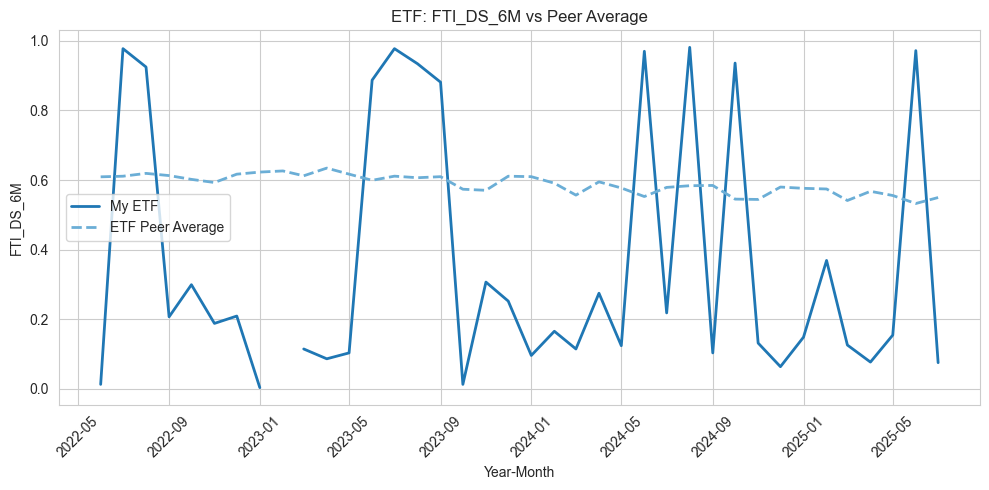

In [32]:
# ETF: FTI_DS_6M vs Peer Average

metric = "FTI_DS_6M"
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    selected_etf_ds["year_month"],
    selected_etf_ds[metric],
    label="My ETF",
    linewidth=2,
    color="#1f77b4",
)
ax.plot(
    selected_etf_ds["year_month"],
    selected_etf_ds[f"{metric}_avg"],
    label="ETF Peer Average",
    linewidth=2,
    linestyle="--",
    color="#6baed6",
)
ax.set_title(f"ETF: {metric} vs Peer Average")
ax.set_xlabel("Year-Month")
ax.set_ylabel(metric)
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.show()


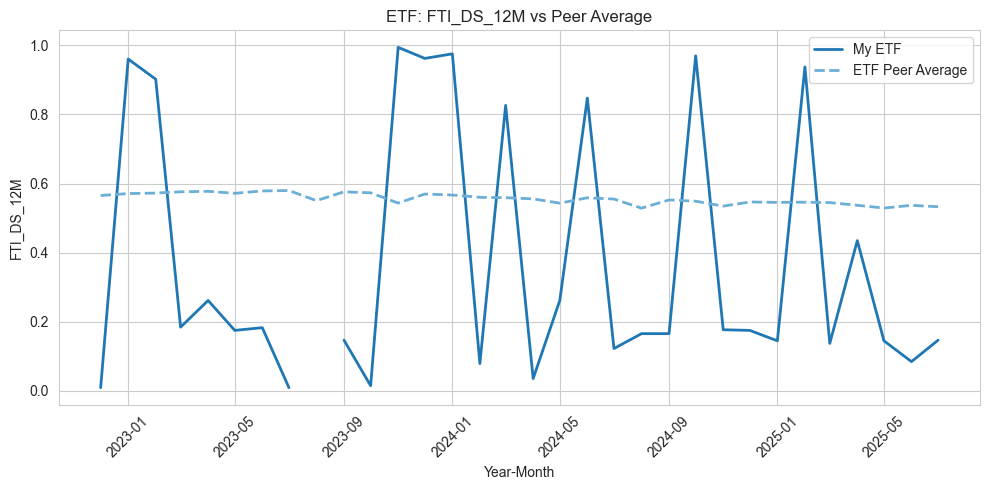

In [33]:
# ETF: FTI_DS_12M vs Peer Average

metric = "FTI_DS_12M"
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    selected_etf_ds["year_month"],
    selected_etf_ds[metric],
    label="My ETF",
    linewidth=2,
    color="#1f77b4",
)
ax.plot(
    selected_etf_ds["year_month"],
    selected_etf_ds[f"{metric}_avg"],
    label="ETF Peer Average",
    linewidth=2,
    linestyle="--",
    color="#6baed6",
)
ax.set_title(f"ETF: {metric} vs Peer Average")
ax.set_xlabel("Year-Month")
ax.set_ylabel(metric)
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.show()


In [34]:
# 5.3.2 Managed Funds: De-seasonalised FTI vs Peer Average

selected_mf_name = "ATLAS Infrastructure (Australia) - Atlas Infrastructure Australian Feeder Fund - Hedged"

mf_ds_plot_df = managed_funds_fti_ds.copy()
mf_ds_plot_df["year_month"] = pd.to_datetime(mf_ds_plot_df["year_month"], errors="coerce")

ds_metrics = ["FTI_DS", "FTI_DS_3M", "FTI_DS_6M", "FTI_DS_12M"]

mf_ds_avg = (
    mf_ds_plot_df.groupby("year_month", as_index=False)[ds_metrics]
    .mean()
    .rename(columns={col: f"{col}_avg" for col in ds_metrics})
)

selected_mf_ds = (
    mf_ds_plot_df[mf_ds_plot_df["securityname"] == selected_mf_name]
    .sort_values("year_month")
    .merge(mf_ds_avg, on="year_month", how="left")
    .reset_index(drop=True)
)

sns.set_style("whitegrid")


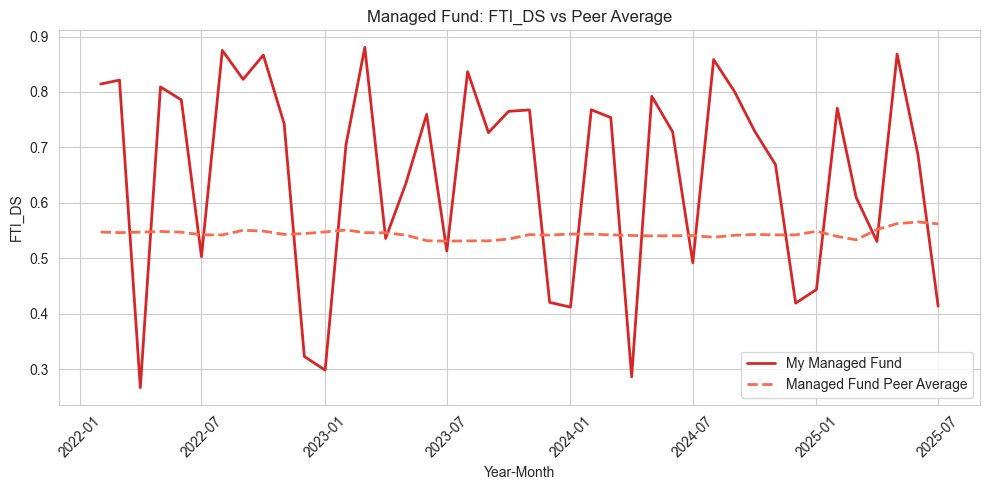

In [35]:
# Managed Fund: FTI_DS vs Peer Average

metric = "FTI_DS"
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    selected_mf_ds["year_month"],
    selected_mf_ds[metric],
    label="My Managed Fund",
    linewidth=2,
    color="#d62728",
)
ax.plot(
    selected_mf_ds["year_month"],
    selected_mf_ds[f"{metric}_avg"],
    label="Managed Fund Peer Average",
    linewidth=2,
    linestyle="--",
    color="#fb6a4a",
)
ax.set_title(f"Managed Fund: {metric} vs Peer Average")
ax.set_xlabel("Year-Month")
ax.set_ylabel(metric)
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.show()


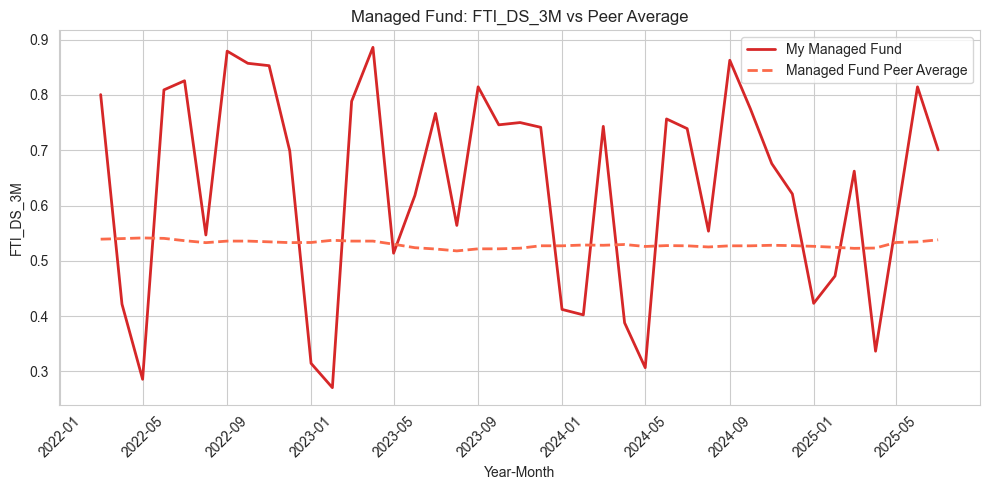

In [36]:
# Managed Fund: FTI_DS_3M vs Peer Average

metric = "FTI_DS_3M"
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    selected_mf_ds["year_month"],
    selected_mf_ds[metric],
    label="My Managed Fund",
    linewidth=2,
    color="#d62728",
)
ax.plot(
    selected_mf_ds["year_month"],
    selected_mf_ds[f"{metric}_avg"],
    label="Managed Fund Peer Average",
    linewidth=2,
    linestyle="--",
    color="#fb6a4a",
)
ax.set_title(f"Managed Fund: {metric} vs Peer Average")
ax.set_xlabel("Year-Month")
ax.set_ylabel(metric)
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.show()


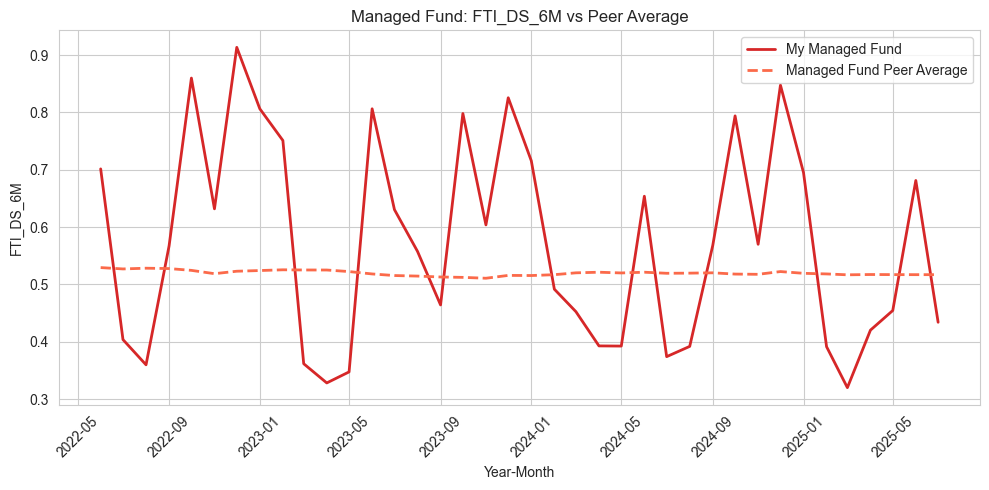

In [37]:
# Managed Fund: FTI_DS_6M vs Peer Average

metric = "FTI_DS_6M"
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    selected_mf_ds["year_month"],
    selected_mf_ds[metric],
    label="My Managed Fund",
    linewidth=2,
    color="#d62728",
)
ax.plot(
    selected_mf_ds["year_month"],
    selected_mf_ds[f"{metric}_avg"],
    label="Managed Fund Peer Average",
    linewidth=2,
    linestyle="--",
    color="#fb6a4a",
)
ax.set_title(f"Managed Fund: {metric} vs Peer Average")
ax.set_xlabel("Year-Month")
ax.set_ylabel(metric)
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.show()


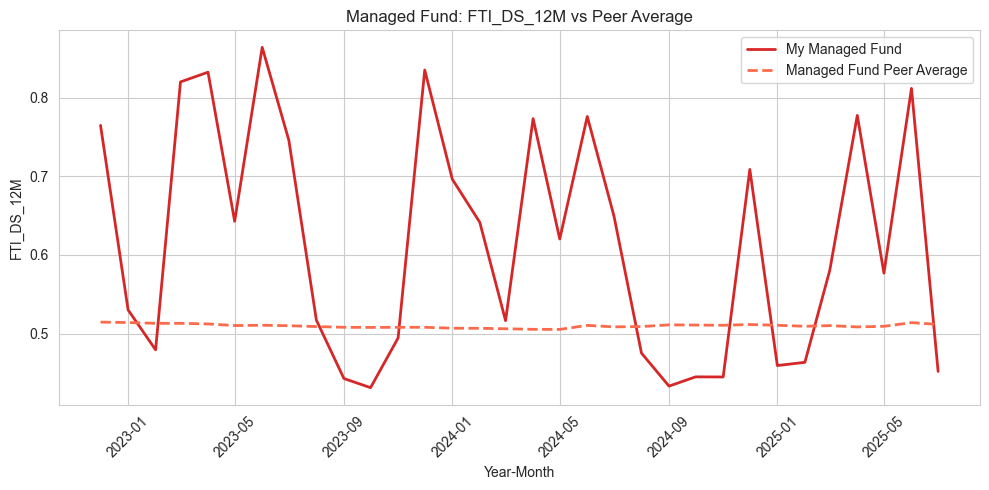

In [38]:
# Managed Fund: FTI_DS_12M vs Peer Average

metric = "FTI_DS_12M"
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    selected_mf_ds["year_month"],
    selected_mf_ds[metric],
    label="My Managed Fund",
    linewidth=2,
    color="#d62728",
)
ax.plot(
    selected_mf_ds["year_month"],
    selected_mf_ds[f"{metric}_avg"],
    label="Managed Fund Peer Average",
    linewidth=2,
    linestyle="--",
    color="#fb6a4a",
)
ax.set_title(f"Managed Fund: {metric} vs Peer Average")
ax.set_xlabel("Year-Month")
ax.set_ylabel(metric)
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.show()


# 6. Sample calculation

In [39]:
# Show the sample fund in 2024-11 and 2024-12

selected_mf_name = "ATLAS Infrastructure (Australia) - Atlas Infrastructure Australian Feeder Fund - Hedged"
target_months = ["2024-11", "2024-12"]

sample_mf = managed_funds_fti[
    (managed_funds_fti["securityname"] == selected_mf_name) &
    (managed_funds_fti["year_month"].isin(target_months))
].copy()

print("Managed Funds sample data in 2024-11 and 2024-12:")
with pd.option_context(
    "display.max_colwidth", None,
    "display.width", None,
    "display.max_columns", None
):
    display(sample_mf)

Managed Funds sample data in 2024-11 and 2024-12:


,securityname,year_month,netflow,FTI,FTI_3M,FTI_6M,FTI_12M
464,ATLAS Infrastructure (Australia) - Atlas Infrastructure Australian Feeder Fund - Hedged,2024-11,7.517468e+06,0.516461,0.564583,0.803758,0.580042
465,ATLAS Infrastructure (Australia) - Atlas Infrastructure Australian Feeder Fund - Hedged,2024-12,5.798240e+06,0.591463,0.462963,0.798000,0.633124


In [40]:
selected_mf_name = "ATLAS Infrastructure (Australia) - Atlas Infrastructure Australian Feeder Fund - Hedged"
target_months = ["2024-11", "2024-12"]

sample_mf_ds = managed_funds_fti_ds[
    (managed_funds_fti_ds["securityname"] == selected_mf_name) &
    (managed_funds_fti_ds["year_month"].isin(target_months))
][
    [
        "securityname",
        "year_month",
        "seasonal_component",
        "netflow",
        "netflow_deseasonalized",
        "FTI_DS",
        "FTI_DS_3M",
        "FTI_DS_6M",
        "FTI_DS_12M",
    ]
].copy()

print("Managed Fund de-seasonalised sample data in 2024-11 and 2024-12:")
with pd.option_context(
    "display.max_colwidth", None,
    "display.width", None,
    "display.max_columns", None
):
    display(sample_mf_ds)

Managed Fund de-seasonalised sample data in 2024-11 and 2024-12:


,securityname,year_month,seasonal_component,netflow,netflow_deseasonalized,FTI_DS,FTI_DS_3M,FTI_DS_6M,FTI_DS_12M
464,ATLAS Infrastructure (Australia) - Atlas Infrastructure Australian Feeder Fund - Hedged,2024-11,3.09,7.517468e+06,7.517465e+06,0.668956,0.675824,0.570055,0.444904
465,ATLAS Infrastructure (Australia) - Atlas Infrastructure Australian Feeder Fund - Hedged,2024-12,120.00,5.798240e+06,5.798120e+06,0.418956,0.620879,0.847527,0.708791


In [41]:
def plot_sample_calculation_dashboard(df, fund_name, target_month, title_prefix, color):
    df2 = df.copy()

    df2["year_month"] = pd.to_datetime(df2["year_month"], errors="coerce")
    target_month = pd.to_datetime(target_month)

    sample_df = df2[
        (df2["securityname"] == fund_name) &
        (df2["year_month"] == target_month)
    ]

    row = sample_df.iloc[0]

    x = ["1M", "3M", "6M", "12M"]
    y = [row["FTI"], row["FTI_3M"], row["FTI_6M"], row["FTI_12M"]]

    plt.figure(figsize=(8, 5))
    plt.suptitle(
        f"{title_prefix} Sample Calculation Visualisation ({target_month.strftime('%Y-%m')})",
        fontsize=15,
        fontweight="bold"
    )

    bars = plt.bar(x, y, color=color, alpha=0.85)

    plt.axhline(y=0.5, color="gray", linestyle="--", linewidth=1, label="Peer mid-point (0.5)")
    plt.ylim(0, 1)
    plt.title("FTI by Horizon")
    plt.xlabel("Horizon")
    plt.ylabel("FTI Value")
    plt.legend()

    for i in range(len(y)):
        if pd.notna(y[i]):
            plt.text(
                i,
                y[i] + 0.02,
                f"{y[i]:.3f}",
                ha="center",
                va="bottom",
                fontsize=10
            )

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

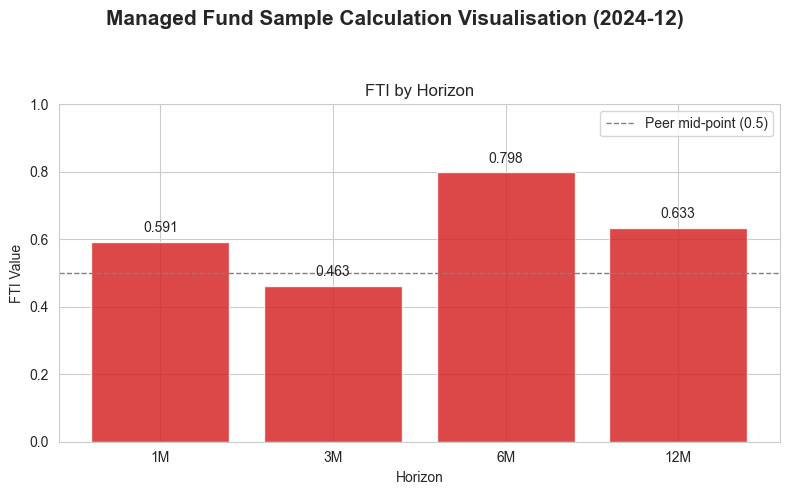

In [42]:
target_month = "2024-12"

plot_sample_calculation_dashboard(
    managed_funds_fti,
    "ATLAS Infrastructure (Australia) - Atlas Infrastructure Australian Feeder Fund - Hedged",
    target_month,
    "Managed Fund",
    "#d62728"
)